In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder,StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import shap
from sklearn.model_selection import cross_val_score

## Data Loading

In [2]:
df = pd.read_csv(r"C:\Users\Dell\OneDrive\Desktop\Turbine Health Monitoring\wind turbine data set.csv")
df.head()

,TurbineID,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure,FaultType
0,T56,23.9,12.3,34,98,77,0.98,936,65,27,143,0,NaN
1,T46,12.6,17.6,27,84,86,0.70,1517,74,33,221,0,NaN
2,T47,22.4,18.0,30,94,86,0.76,1460,73,16,151,0,NaN
3,T79,12.9,18.0,27,71,88,0.74,1134,68,32,169,0,NaN
4,T16,8.6,13.8,27,79,93,1.33,1485,79,21,180,1,Generator


In [3]:
df.head()

,TurbineID,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure,FaultType
0,T56,23.9,12.3,34,98,77,0.98,936,65,27,143,0,NaN
1,T46,12.6,17.6,27,84,86,0.70,1517,74,33,221,0,NaN
2,T47,22.4,18.0,30,94,86,0.76,1460,73,16,151,0,NaN
3,T79,12.9,18.0,27,71,88,0.74,1134,68,32,169,0,NaN
4,T16,8.6,13.8,27,79,93,1.33,1485,79,21,180,1,Generator


In [4]:
df.tail()

,TurbineID,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure,FaultType
8995,T12,19.3,13.0,20,77,89,1.26,1409,62,30,267,0,NaN
8996,T49,13.9,16.0,34,95,84,1.31,1428,64,21,124,1,Gearbox
8997,T95,10.7,18.1,32,98,92,1.01,1230,65,34,115,0,NaN
8998,T82,15.5,10.6,42,91,92,0.91,1305,66,25,213,0,NaN
8999,T46,12.6,19.5,39,75,81,0.82,1968,65,33,107,0,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TurbineID                 9000 non-null   object 
 1   WindSpeed                 9000 non-null   float64
 2   RotorSpeed                9000 non-null   float64
 3   BladeAngle                9000 non-null   int64  
 4   GearboxTemp               9000 non-null   int64  
 5   GeneratorTemp             9000 non-null   int64  
 6   Vibration                 9000 non-null   float64
 7   PowerOutput               9000 non-null   int64  
 8   Humidity                  9000 non-null   int64  
 9   AmbientTemperature        9000 non-null   int64  
 10  TimeSinceLastMaintenance  9000 non-null   int64  
 11  Failure                   9000 non-null   int64  
 12  FaultType                 1152 non-null   object 
dtypes: float64(3), int64(8), object(2)
memory usage: 914.2+ KB


In [6]:
df.describe()

,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,14.972944,15.014489,30.020556,85.066222,85.121000,1.001574,1447.854556,70.033556,24.961667,164.715444,0.128000
std,5.786175,2.882054,8.685036,8.653435,5.783124,0.290811,319.898071,5.742907,5.756860,77.479453,0.334108
min,5.000000,10.000000,15.000000,70.000000,75.000000,0.500000,900.000000,60.000000,15.000000,30.000000,0.000000
25%,9.900000,12.500000,23.000000,78.000000,80.000000,0.750000,1171.000000,65.000000,20.000000,98.750000,0.000000
50%,14.900000,15.100000,30.000000,85.000000,85.000000,1.000000,1441.000000,70.000000,25.000000,164.000000,0.000000
75%,20.000000,17.500000,38.000000,93.000000,90.000000,1.260000,1728.000000,75.000000,30.000000,232.000000,0.000000
max,25.000000,20.000000,45.000000,100.000000,95.000000,1.500000,2000.000000,80.000000,35.000000,299.000000,1.000000


In [7]:
df.shape

(9000, 13)

In [8]:
df.columns

Index(['TurbineID', 'WindSpeed', 'RotorSpeed', 'BladeAngle', 'GearboxTemp',
       'GeneratorTemp', 'Vibration', 'PowerOutput', 'Humidity',
       'AmbientTemperature', 'TimeSinceLastMaintenance', 'Failure',
       'FaultType'],
      dtype='object')

## Data Cleaning

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

TurbineID                      0
WindSpeed                      0
RotorSpeed                     0
BladeAngle                     0
GearboxTemp                    0
GeneratorTemp                  0
Vibration                      0
PowerOutput                    0
Humidity                       0
AmbientTemperature             0
TimeSinceLastMaintenance       0
Failure                        0
FaultType                   7848
dtype: int64

In [11]:
df["FaultType"] = df["FaultType"].fillna("No Fault")

In [12]:
df.isnull().sum()

TurbineID                   0
WindSpeed                   0
RotorSpeed                  0
BladeAngle                  0
GearboxTemp                 0
GeneratorTemp               0
Vibration                   0
PowerOutput                 0
Humidity                    0
AmbientTemperature          0
TimeSinceLastMaintenance    0
Failure                     0
FaultType                   0
dtype: int64

In [13]:
df.head()

,TurbineID,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure,FaultType
0,T56,23.9,12.3,34,98,77,0.98,936,65,27,143,0,No Fault
1,T46,12.6,17.6,27,84,86,0.70,1517,74,33,221,0,No Fault
2,T47,22.4,18.0,30,94,86,0.76,1460,73,16,151,0,No Fault
3,T79,12.9,18.0,27,71,88,0.74,1134,68,32,169,0,No Fault
4,T16,8.6,13.8,27,79,93,1.33,1485,79,21,180,1,Generator


In [14]:
df['FaultType'].value_counts()

FaultType
No Fault     7848
Gearbox       586
Blades        314
Generator     252
Name: count, dtype: int64

## Feature Engineering

In [15]:
df["Temperature Difference"]=df['GearboxTemp']-df['GeneratorTemp']

In [16]:
df['Vibration Load']= df['Vibration'] * df['RotorSpeed']

In [17]:
df['Vibration Ratio'] = df['Vibration'] / (df['RotorSpeed'] + 1)

In [18]:
df['MaintenanceRisk'] = df['TimeSinceLastMaintenance'] * df['Vibration']

In [19]:
df.head()

,TurbineID,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure,FaultType,Temperature Difference,Vibration Load,Vibration Ratio,MaintenanceRisk
0,T56,23.9,12.3,34,98,77,0.98,936,65,27,143,0,No Fault,21,12.054,0.073684,140.14
1,T46,12.6,17.6,27,84,86,0.70,1517,74,33,221,0,No Fault,-2,12.320,0.037634,154.70
2,T47,22.4,18.0,30,94,86,0.76,1460,73,16,151,0,No Fault,8,13.680,0.040000,114.76
3,T79,12.9,18.0,27,71,88,0.74,1134,68,32,169,0,No Fault,-17,13.320,0.038947,125.06
4,T16,8.6,13.8,27,79,93,1.33,1485,79,21,180,1,Generator,-14,18.354,0.089865,239.40


## Outlier Detection

In [20]:
cols = [
    'Vibration',
    'GearboxTemp',
    'GeneratorTemp',
    'WindSpeed',
    'RotorSpeed',
    'BladeAngle'
]

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[~((df[cols] < lower) | (df[cols] > upper)).any(axis=1)]

## Exploratory Data Analysis (EDA)

In [21]:
df.describe()

,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure,Temperature Difference,Vibration Load,Vibration Ratio,MaintenanceRisk
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,14.972944,15.014489,30.020556,85.066222,85.121000,1.001574,1447.854556,70.033556,24.961667,164.715444,0.128000,-0.054778,15.043398,0.064684,164.726368
std,5.786175,2.882054,8.685036,8.653435,5.783124,0.290811,319.898071,5.742907,5.756860,77.479453,0.334108,10.348436,5.319108,0.022620,93.171166
min,5.000000,10.000000,15.000000,70.000000,75.000000,0.500000,900.000000,60.000000,15.000000,30.000000,0.000000,-25.000000,5.050000,0.024038,15.900000
25%,9.900000,12.500000,23.000000,78.000000,80.000000,0.750000,1171.000000,65.000000,20.000000,98.750000,0.000000,-8.000000,10.885250,0.046667,89.787500
50%,14.900000,15.100000,30.000000,85.000000,85.000000,1.000000,1441.000000,70.000000,25.000000,164.000000,0.000000,0.000000,14.400000,0.062436,149.725000
75%,20.000000,17.500000,38.000000,93.000000,90.000000,1.260000,1728.000000,75.000000,30.000000,232.000000,0.000000,8.000000,18.685000,0.079262,226.002500
max,25.000000,20.000000,45.000000,100.000000,95.000000,1.500000,2000.000000,80.000000,35.000000,299.000000,1.000000,25.000000,29.800000,0.134234,439.530000


In [22]:
df['Failure'].value_counts

<bound method IndexOpsMixin.value_counts of 0       0
1       0
2       0
3       0
4       1
       ..
8995    0
8996    1
8997    0
8998    0
8999    0
Name: Failure, Length: 9000, dtype: int64>

In [23]:
numeric_df = df.select_dtypes(include=['number'])

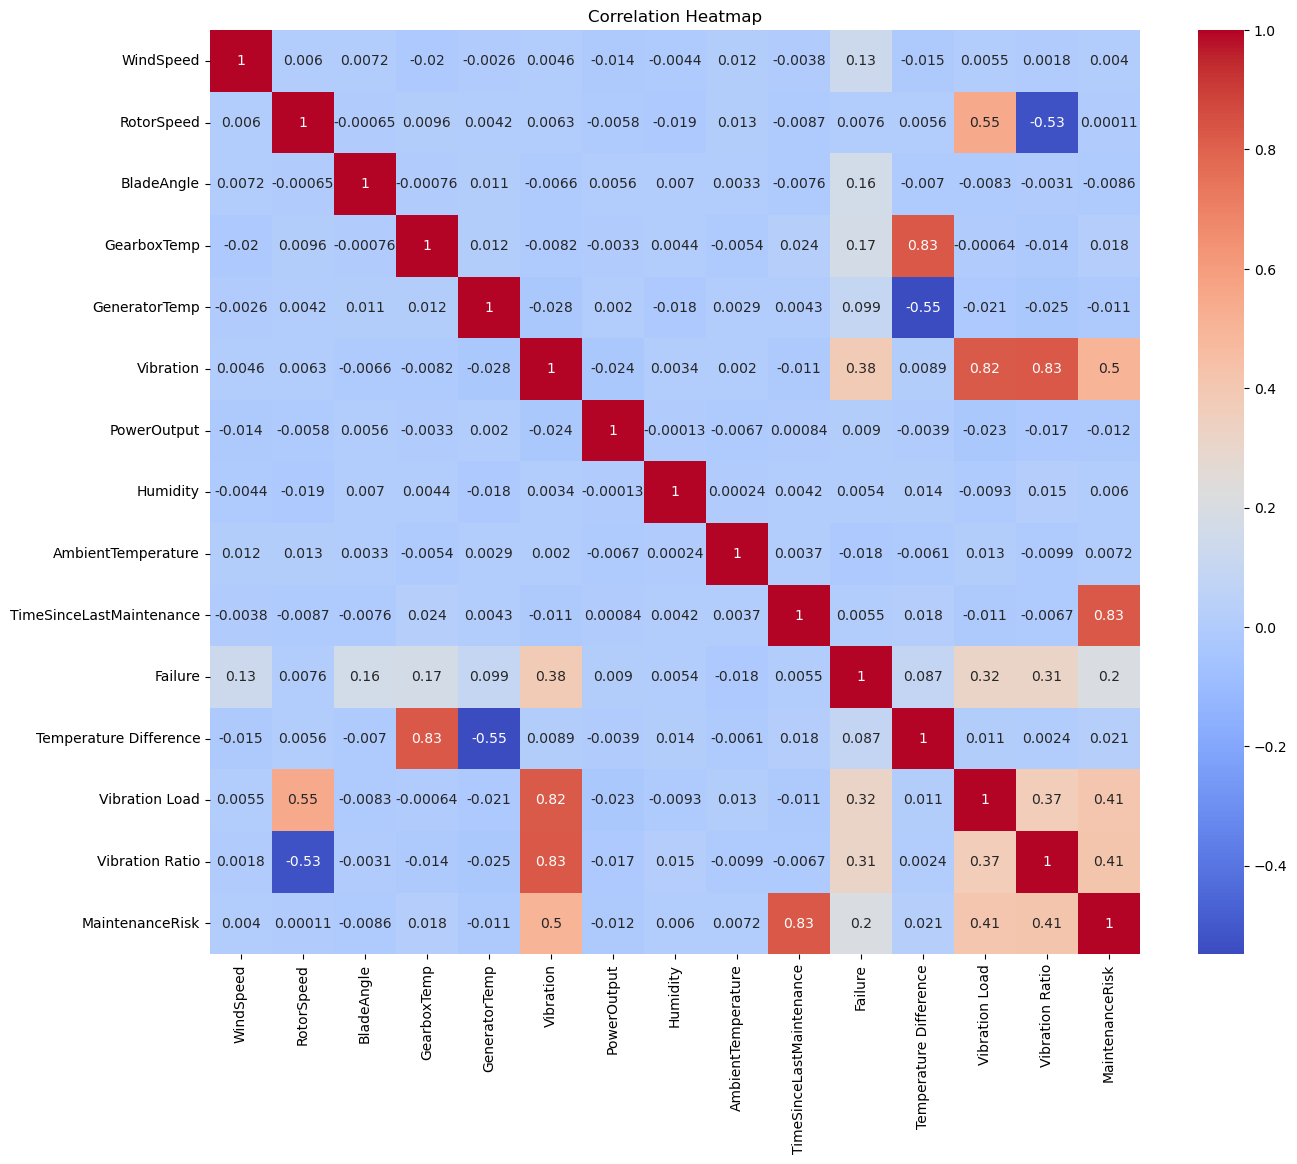

In [24]:
# Heatmap 
plt.figure(figsize=(15,12)) 
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap") 
plt.show()

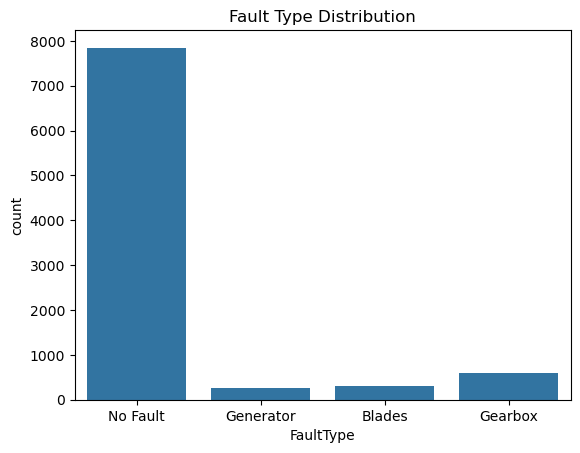

In [25]:
#Fault Type Distribution
sns.countplot(x='FaultType', data=df)
plt.title("Fault Type Distribution")
plt.show()

Text(0.5, 1.0, 'Target Variable')

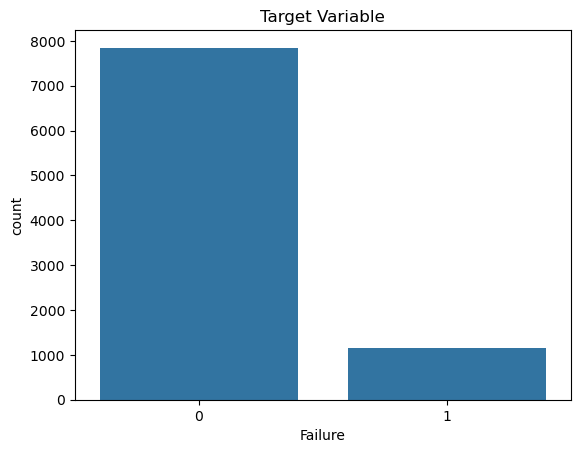

In [26]:
# Target Variable
sns.countplot(x='Failure', data=df)
plt.title("Target Variable")

<Axes: xlabel='Failure', ylabel='Vibration'>

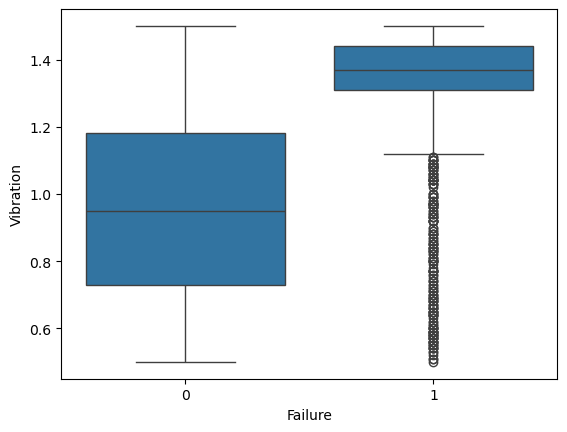

In [27]:
# vibration values vs failed or non failed turbine 
sns.boxplot(x='Failure', y='Vibration', data=df)

<Axes: xlabel='WindSpeed', ylabel='PowerOutput'>

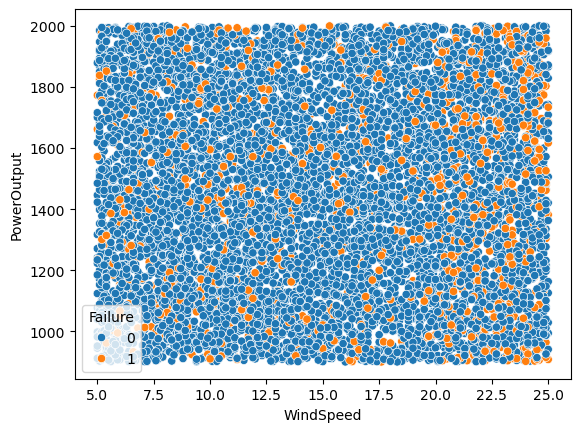

In [28]:
sns.scatterplot(x='WindSpeed', y='PowerOutput', hue='Failure', data=df)

## Encoding the column

In [29]:
le = LabelEncoder()
df['FaultType'] = le.fit_transform(df['FaultType'])

## Feature Selection

In [30]:
# Use only core sensor features
drop_cols = [
    'Failure',
    'FaultType',
    'TurbineID',
    'TempDifference',
]

X = df.drop(columns=drop_cols, errors='ignore')
y = df['Failure']

print(X.columns)
print(X.shape)

Index(['WindSpeed', 'RotorSpeed', 'BladeAngle', 'GearboxTemp', 'GeneratorTemp',
       'Vibration', 'PowerOutput', 'Humidity', 'AmbientTemperature',
       'TimeSinceLastMaintenance', 'Temperature Difference', 'Vibration Load',
       'Vibration Ratio', 'MaintenanceRisk'],
      dtype='object')
(9000, 14)


## Train Test Split

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [32]:
y_train.value_counts()
y_test.value_counts()

Failure
0    1575
1     225
Name: count, dtype: int64

## Model Training

In [33]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=2,
        min_samples_leaf=20,
        min_samples_split=25,
        class_weight='balanced',
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=80,
        max_depth=3,
        min_samples_leaf=2,
        min_samples_split=6,
        class_weight='balanced',
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=50,
        max_depth=2,
        learning_rate=0.02,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1,
        reg_lambda=2,
        eval_metric='logloss',
        random_state=42
    )
}

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

for name, model in models.items():
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > 0.3).astype(int)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
Accuracy: 0.8861111111111111
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      1575
           1       0.54      0.66      0.59       225

    accuracy                           0.89      1800
   macro avg       0.74      0.79      0.76      1800
weighted avg       0.90      0.89      0.89      1800

[[1446  129]
 [  76  149]]

Decision Tree
Accuracy: 0.8138888888888889
              precision    recall  f1-score   support

           0       1.00      0.79      0.88      1575
           1       0.40      1.00      0.57       225

    accuracy                           0.81      1800
   macro avg       0.70      0.89      0.73      1800
weighted avg       0.93      0.81      0.84      1800

[[1240  335]
 [   0  225]]

Random Forest
Accuracy: 0.7655555555555555
              precision    recall  f1-score   support

           0       1.00      0.73      0.85      1575
           1       0.35      1.00      0.52  

## Cross Validation

In [35]:
model = XGBClassifier(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.02,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,
    reg_lambda=2,
    eval_metric='logloss',
    random_state=42
)

In [36]:
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("Scores:", scores)
print("Mean Accuracy:", scores.mean())

Scores: [0.88777778 0.88944444 0.88888889 0.88777778 0.88833333]
Mean Accuracy: 0.8884444444444446


In [37]:
scores = cross_val_score(model, X, y, cv=5, scoring='f1')

print("F1 Scores:", scores)
print("Mean F1:", scores.mean())

F1 Scores: [0.21705426 0.23754789 0.23076923 0.22307692 0.22988506]
Mean F1: 0.22766667352072326


## Fault Type Prediction

In [38]:
df_fault = df[df['Failure'] == 1]

In [39]:
X = df_fault.drop(['Failure', 'FaultType','TurbineID'], axis=1)
y = df_fault['FaultType']

In [40]:
le = LabelEncoder()
y = le.fit_transform(y)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [42]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [43]:
y_pred = model.predict(X_test)

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00       117
           2       1.00      1.00      1.00        51

    accuracy                           1.00       231
   macro avg       1.00      1.00      1.00       231
weighted avg       1.00      1.00      1.00       231



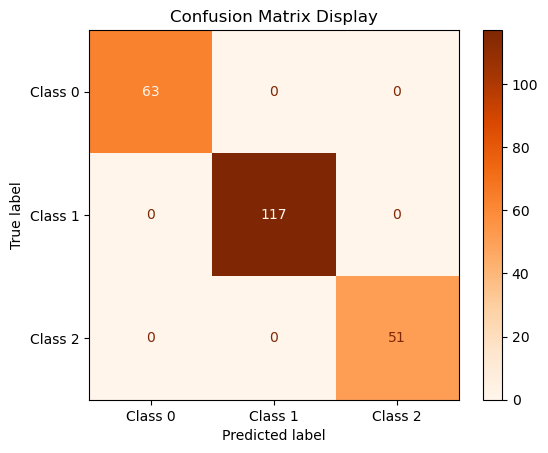

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Class 0', 'Class 1', 'Class 2'])

disp.plot(cmap='Oranges')
plt.title("Confusion Matrix Display")
plt.show()

## Hyper Parameter Tuning

In [46]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
}
model = XGBClassifier(eval_metric='logloss', random_state=42)
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,                 # number of combinations
    scoring='f1_weighted',              # important for imbalance
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.2],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [2, 3, 4, 5],
                                        'n_estimators': [50, 100, 150, 200],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='f1_weighted', verbose=1)

In [47]:
print("Best Params:", random_search.best_params_)

Best Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}


In [48]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00       117
           2       1.00      1.00      1.00        51

    accuracy                           1.00       231
   macro avg       1.00      1.00      1.00       231
weighted avg       1.00      1.00      1.00       231



## Post Model Analysis - Feature Importance

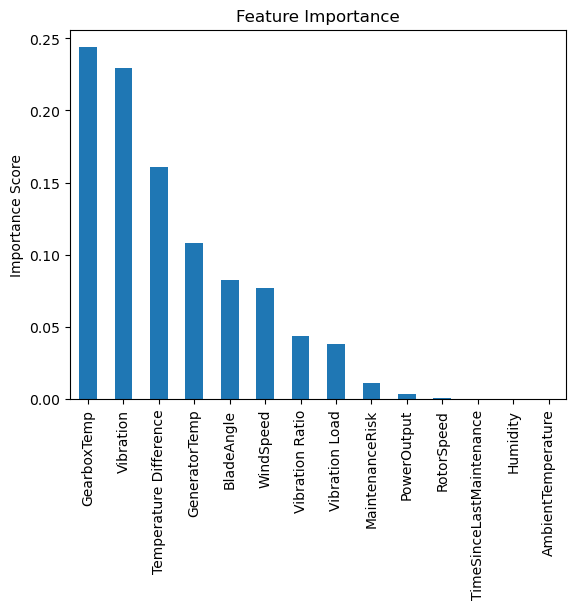

In [49]:
importance = best_model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

# Plot
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()

 96%|=================== | 3317/3456 [00:19<00:00]       

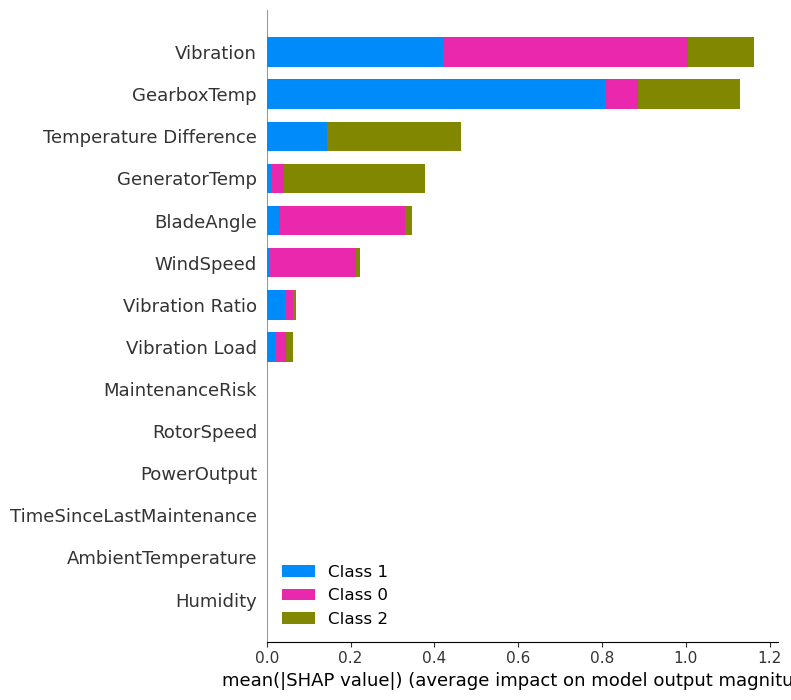

In [50]:
explainer = shap.Explainer(best_model, X)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

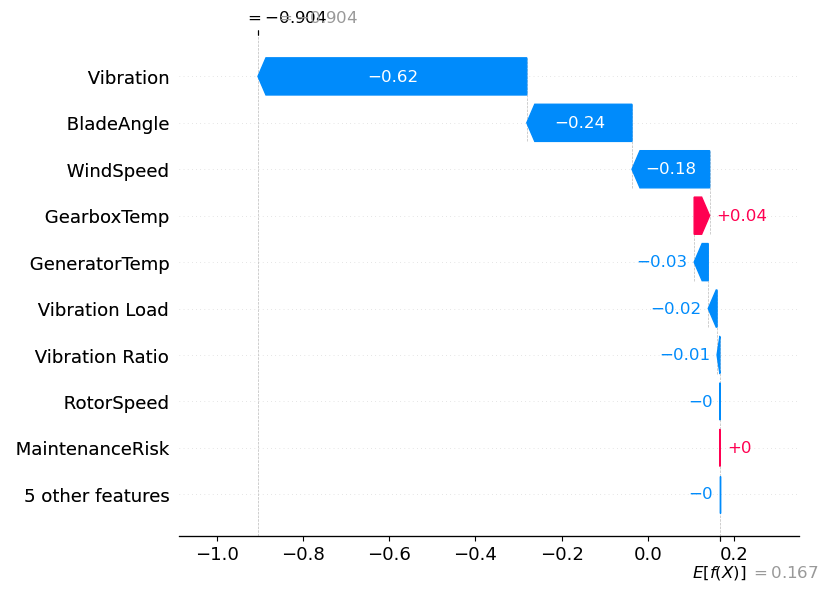

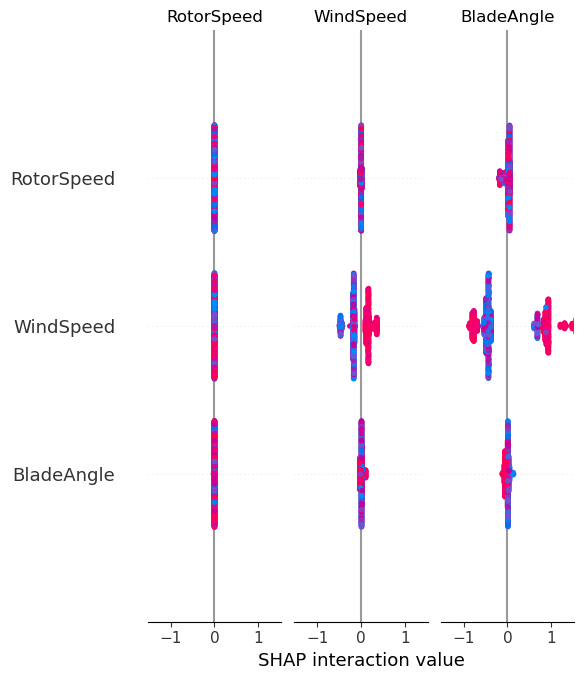

In [51]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[0],
    shap_values[0][:, 0],
    X.iloc[0]
)
shap.summary_plot(shap_values, X)

## Prediction

In [52]:
import joblib

joblib.dump(best_model, "turbine_model.pkl")

['turbine_model.pkl']

In [53]:
import joblib

joblib.dump(best_model, "fault_type_model.pkl")

['fault_type_model.pkl']

In [64]:
import numpy as np
import joblib

# load both models
health_model = joblib.load("turbine_model.pkl")
fault_model = joblib.load("fault_type_model.pkl")

fault_labels = {
    0: "Blade Fault",
    1: "Gearbox Fault",
    2: "Generator Fault",
    3: "Normal"
}

def validate_input(value, min_val, max_val, field_name):
    if value < min_val or value > max_val:
        raise ValueError(f"{field_name} should be between {min_val} and {max_val}")
    return value

def predict_turbine_status(data_14):
    health_pred = health_model.predict(data_14)[0]

    if health_pred == 0:
        return "Turbine is Healthy"

    else:
        fault_pred = fault_model.predict(data_14)[0]
        fault_type = fault_labels[fault_pred]

        return f"Failure Detected - {fault_type}"

try:
    print("Enter turbine sensor values:\n")

    wind = validate_input(float(input("Wind Speed: ")), 0, 50, "Wind Speed")
    rotor = validate_input(float(input("Rotor Speed: ")), 0, 50, "Rotor Speed")
    blade = validate_input(float(input("Blade Angle: ")), 0, 90, "Blade Angle")
    gear = validate_input(float(input("Gearbox Temp: ")), 0, 120, "Gearbox Temp")
    gen = validate_input(float(input("Generator Temp: ")), 0, 120, "Generator Temp")
    vib = validate_input(float(input("Vibration: ")), 0, 10, "Vibration")
    power = validate_input(float(input("Power Output: ")), 0, 3000, "Power Output")
    hum = validate_input(float(input("Humidity: ")), 0, 100, "Humidity")
    amb = validate_input(float(input("Ambient Temperature: ")), -10, 60, "Ambient Temperature")
    maint = validate_input(float(input("Time Since Last Maintenance: ")), 0, 1000, "Maintenance")

    # engineered features
    temp_diff = gear - gen
    vibration_load=vib * rotor
    vibration_ratio = vib / (rotor + 1e-5)
    maintenance_risk = maint * vib

    # same 14 features for both models
    data_14 = [[
        wind,
        rotor,
        blade,
        gear,
        gen,
        vib,
        power,
        hum,
        amb,
        maint,
        temp_diff,
        vibration_load,
        vibration_ratio,
        maintenance_risk
    ]]

    result = predict_turbine_status(data_14)

    print("\nFinal Prediction:")
    print(result)

except ValueError as e:
    print("\nInvalid Input:", e)

Enter turbine sensor values:



Wind Speed:  30
Rotor Speed:  12
Blade Angle:  20
Gearbox Temp:  40
Generator Temp:  100
Vibration:  7
Power Output:  600
Humidity:  75
Ambient Temperature:  30
Time Since Last Maintenance:  300



Final Prediction:
Failure Detected - Generator Fault


In [55]:
## Failure Detected due to TempDifference=40−100=−60 so more temp diff refers to generator fault
# Powerefficiency = power output / wind speed
# Maintenance Risk = timesince last maintenance * vibration